## Import necessary packages 

In [1]:
# Python modules 
import numpy as np
# import matplotlib
import matplotlib.pyplot as plt
# matplotlib.rcParams.update(matplotlib.rcParamsDefault)
import pandas as pd
import importlib
from numpy import loadtxt
# from matplotlib import gridspec # for the contour plots
from cvxopt import matrix, solvers

# pyDRTtools' modules
import pyDRTtools
import pyDRTtools.basics as basics # pyDRTtools functions
# import pyDRTtools.GUI as UI

import os
from glob import glob
from natsort import natsorted
import h5py


Initializing pyDRTtools from C:\Users\Herman\anaconda3\lib\site-packages
['', 'C:\\Users\\Herman\\psi4conda\\Lib\\site-packages', 'C:\\Users\\Herman\\psi4conda\\Lib\\site-packages\\_plotly_utils', 'C:\\Users\\Herman\\.spyder-py3', 'C:\\Users\\Herman\\anaconda3\\python38.zip', 'C:\\Users\\Herman\\anaconda3\\DLLs', 'C:\\Users\\Herman\\anaconda3\\lib', 'C:\\Users\\Herman\\anaconda3', 'C:\\Users\\Herman\\anaconda3\\lib\\site-packages', 'C:\\Users\\Herman\\anaconda3\\lib\\site-packages\\win32', 'C:\\Users\\Herman\\anaconda3\\lib\\site-packages\\win32\\lib', 'C:\\Users\\Herman\\anaconda3\\lib\\site-packages\\Pythonwin', 'C:\\Users\\Herman\\anaconda3\\lib\\site-packages\\setuptools\\_vendor']
Imported basics
Imported BHT
Imported HMC
Imported nearest_PD
Imported parameter_selection
Imported peak_analysis
Imported runs
Contents of pyDRTtools package: ['basics', 'parameter_selection', 'peak_analysis', 'HMC', 'runs', 'nearest_PD']


#### 2.1 Load and analyze many EIS spectra concomitantly

In [2]:
   
def get_header_lines(filepath):
    with open(filepath, "r", encoding="latin-1") as f:
        # Skip first line, read second
        f.readline()  
        line2 = f.readline().strip()
    # line2 looks like: "Nb header lines : 76"
    # split by ":" and take the right part
    try:
        n_header = int(line2.split(":")[1])
    except Exception:
        raise ValueError(f"Could not parse header line: {line2}")
    return n_header

def drt_to_impedance(tau, gamma, freq, R_inf=0.0, L = 0):
    """
    Convert DRT spectrum to complex impedance.

    Parameters
    ----------
    tau : array_like
        Relaxation times (s), log-spaced
    gamma : array_like
        DRT values (Ohm)
    freq : array_like
        Frequencies (Hz)
    R_inf : float, optional
        High-frequency resistance (Ohm)

    Returns
    -------
    Z : ndarray
        Complex impedance at each frequency
    """
    omega = 2 * np.pi * freq
    ln_tau = np.log(tau)

    Z = np.zeros(len(freq), dtype=complex)

    for i, w in enumerate(omega):
        kernel = gamma / (1 + 1j * w * tau)
        Z[i] = R_inf + 1j*w*L+ np.trapz(kernel, ln_tau)

    return Z

def get_EIS_setting(file_path):
    with open(file_path, "r") as file:
        E = 'Ewe'
        for line_number, line in enumerate(file, start=1):
            if "Potential control" in line:
                E = line.split(': ')[1][:-1]
            if "Current amplifier" in line:
                booster = line.split(': ')[1][:-1]
    return E,booster



def save_impedance_to_h5(file_in, file_out,cycles = None, cycle_col="cycle number", metadata=None):
    """
    df: pandas DataFrame with multiple spectra
    cycle_col: column that identifies each spectrum
    global_metadata: dict stored at file level (optional)
    """
    
    skip_rows = get_header_lines(file_in)
    with open(file_in, encoding='latin1') as f:
        df = pd.read_csv(f,skiprows = skip_rows-1,usecols=np.arange(0,30),delimiter = '\t')
    # print(df)
    E_control, booster = get_EIS_setting(file_in)
    if E_control == 'Ewe':
        columns = ['freq/Hz', 'Re(Z)/Ohm','-Im(Z)/Ohm','<Ewe>/V','time/s','<I>/mA']
    elif E_control == 'Ewe-Ece':
        columns = ['freq/Hz', 'Re(Zwe-ce)/Ohm','-Im(Zwe-ce)/Ohm','<Ewe>/V','time/s','<I>/mA']

    
    unique_vals = np.unique(df["cycle number"].values)
    if cycles is None:
        cycles = unique_vals
    with h5py.File(file_out, "a") as f:

        # Store global metadata
        if metadata is not None:
            for k, v in global_metadata.items():
                f.attrs[k] = v

        # Group by spectrum
        for cycle, group in df.groupby(cycle_col):
            if cycle in cycles:
                group_name = f"spectrum_{(int(cycle)):02d}"
                # grp = f.create_group(f"spectrum_{(int(cycle)):02d}")
                if group_name in f:
                    grp = f[group_name]
                else:
                    grp = f.create_group(group_name)
                    
                grp.attrs['E_control'] = E_control
                grp.attrs['booster'] = booster
                grp.attrs['file'] = file_in

                subgroup_name = 'EIS data'
                if subgroup_name in grp:
                    pass
                else:
                    subgrp = grp.create_group(subgroup_name)
                    # Store each column as its own dataset
                    for col in group.columns:
                        # print(col)
                        # if col == cycle_col:
                            # continue  # already encoded in group name
                        if col in columns:
                            data = group[col].to_numpy()
                            col_split = col.split("/")
                            subgrp.create_dataset(str(col_split[0]+' ('+col_split[1]+')'), data=data)

                    # Optionally store per-spectrum metadata
                    subgrp.attrs["cycle number"] = cycle
                    


                    
                # if metadata is not None:
                #     for key, val in metadata.items():
                #         subgrp.attrs[key] = val
    
def save_spectra_h5(filename, tau,gamma, cycle,series,sample_spectrum_number,metadata=None):
    """
    spectra: list of (energy_array, value_array)
    metadata_list: list of dicts (same length as spectra) or None
    """
    dec = np.floor(np.log10(metadata['max_cycle']))+1
    with h5py.File(filename, "a") as f:
        # for i, (tau, gamma) in enumerate(spectra):
            # f"{number}"
        
        group_name = "spectrum_"+str(int(cycle)).zfill(int(dec))
        # grp = f.create_group(f"spectrum_{(int(cycle)):02d}")
        if group_name in f:
            grp = f[group_name]
        else:
            grp = f.create_group(group_name)

        grp.attrs['series'] = series
        grp.attrs['sample_spectrum_number'] = sample_spectrum_number
        subgroup_name = 'DRT data'
        if subgroup_name in grp:
            subgrp = grp[subgroup_name]
        else:
            subgrp = grp.create_group(subgroup_name)
        
        
        if 'tau (s)' in subgrp:
            print(f'DRT spectrum {sample_spectrum_number} already exists')
            subgrp['tau (s)'][:] = tau
            subgrp['gamma'][:] = gamma
            # if metadata is not None:
            #     for key, val in metadata.items():
            #         subgrp.attrs[key] = val
            
        else:
            print(f'Creating new DRT spectrum no. {sample_spectrum_number}')
            subgrp.create_dataset("tau (s)", data = tau)
            subgrp.create_dataset("gamma", data = gamma)
        if metadata is not None:
            for key, val in metadata.items():
                subgrp.attrs[key] = val
            subgrp.attrs["cycle number"] = cycle

In [3]:
shape_control = 'FWHM Coefficient'
coeff = 0.5
# order of the derivative for the differentiation matrix M ('1st', '2nd')
# rbf_type = 'Piecewise Linear'
rbf_type = 'Gaussian'
# rbf_type = 'C0 Matern'
# rbf_type = 'C2 Matern'
# rbf_type = 'C4 Matern'
# rbf_type = 'C6 Matern'
# rbf_type = 'Inverse Quadratic'

In [4]:
cv_type = 'GCV'
# cv_type = 'mGCV'
# cv_type = 'rGCV'
# cv_type = 'LC'
# cv_type = 'kf'
# cv_type = 're-im'

In [24]:
def calculate_DRT(file_in,file_out, sample_spectrum_number=0,series = 0,cycles = None, lambda_value = 0):

    series += 1
    freq_vec_old = [1,2]
    print(file_in)
    skip_rows = get_header_lines(file_in)
    with open(file_in, encoding='latin1') as f:
        df = pd.read_csv(f,skiprows = skip_rows-1,usecols=np.arange(0,30),delimiter = '\t')
        
    unique_vals = np.unique(df["cycle number"].values)

    E = 0
    E_control, booster = get_EIS_setting(file_in)
    print(E_control)


    
    
    if cycles is None:
        cycles = unique_vals
        # cycles = unique_vals[0::100]
    for i,val in enumerate(cycles):
        sample_spectrum_number += 1
        freq_vec = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'freq/Hz'].values)
        # Z_exp = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'Re(Z)/Ohm'].values - 1j*df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '-Im(Z)/Ohm'].values)
        if E_control == 'Ewe':
            Z_exp = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'Re(Z)/Ohm'].values - 1j*df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '-Im(Z)/Ohm'].values)
            E_new = np.mean(df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '<Ewe>/V'].values)
        elif E_control == 'Ewe-Ece':
            Z_exp = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'Re(Zwe-ce)/Ohm'].values - 1j*df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '-Im(Zwe-ce)/Ohm'].values)
            E_new = np.mean(df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '<Ewe-Ece>/V'].values)
        # Z_exp = np.flip(Z_exp)
        # freq_vec = np.flip(freq_vec)
        I = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '<I>/mA'].values)
        time = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'time/s'].values)
        
        if E- E_new> 0.2:
            series += 1
        E = E_new
        
        if np.diff(freq_vec).any() <  0:
            print('problem')
        else:
            pass

        if E < 1.51:
            f_min = 1
        elif 1.51<E<1.61:
            f_min = 3
        elif 1.61<E<1.71:
            f_min = 5
        else:
            f_min = 10

        f_max = 2e4
        mask = (freq_vec > f_min)  & (freq_vec <= f_max)
        mask &= np.isfinite(Z_exp.real) & np.isfinite(Z_exp.imag)
        freq_vec = freq_vec[mask]
        Z_exp = Z_exp[mask]
        if list(freq_vec) == list(freq_vec_old):
            pass
        else:
            freq_vec_old = freq_vec
            
            N_freqs = len(freq_vec)
            N_taus = N_freqs
            tau_vec = 1/freq_vec

            epsilon  = basics.compute_epsilon(freq_vec, coeff, rbf_type, shape_control)

            # step 3: compute the differentiation matrices
            A_re = basics.assemble_A_re(freq_vec, tau_vec, epsilon, rbf_type)
            A_re_R_inf = np.ones((N_freqs, 1))
            A_re_L_0 = np.zeros((N_freqs, 1))
            A_re = np.hstack(( A_re_R_inf, A_re_L_0, A_re))
            A_im = basics.assemble_A_im(freq_vec, tau_vec, epsilon, rbf_type)
            A_im_R_inf = np.zeros((N_freqs, 1))
            A_im_L_0 = 2*np.pi*freq_vec.reshape((N_freqs, 1))
            A_im = np.hstack(( A_im_R_inf, A_im_L_0, A_im))
            A = np.vstack((A_re, A_im))

            # step 4: compute the differentiation matrix
            M2 = np.zeros((N_taus+2, N_taus+2))
            M2[2:,2:] = basics.assemble_M_2(tau_vec, epsilon, rbf_type)
        # step 5: compute the regularization parameter

        
        if lambda_value ==0:
            # lambda_value = -5
            lambda_value = basics.optimal_lambda(A_re, A_im, np.real(Z_exp), np.imag(Z_exp),  M2,'both','yes',     # no inductive part handling
            -5,       # starting log10(lambda) (the code will scan from here)
            'GCV'     # generalized cross-validation
                )[0]
        else:
            lambda_value = basics.optimal_lambda(A_re, A_im, np.real(Z_exp), np.imag(Z_exp),  M2,'both','yes',     # no inductive part handling
            -np.log10(lambda_value),       # starting log10(lambda) (the code will scan from here)
            'GCV'     # generalized cross-validation
                )[0]
        
        
        # step 6: recover the DRT
        ### 
        lb = np.zeros([N_taus+2])
        bound_mat = np.eye(lb.shape[0])
        H_combined, c_combined = basics.quad_format_combined(A_re, A_im, np.real(Z_exp), np.imag(Z_exp), M2, lambda_value)
        print('Lambda: ',lambda_value)
        # set bound constraint
        G = matrix(-np.identity(Z_exp.imag.shape[0]+2))
        h = matrix(np.zeros(Z_exp.imag.shape[0]+2))
        sol = solvers.qp(matrix(H_combined), matrix(c_combined),G,h)
        ## deconvolved DRT
        x = np.array(sol['x']).flatten()
        out_tau,gamma = basics.x_to_gamma(x[2:], tau_vec, tau_vec, epsilon, rbf_type)
        plt.plot(out_tau, gamma)
        plt.xscale('log')
        plt.show()
        metadata = {'f min (Hz)' : f_min,'f max (Hz)' : f_max ,'E (V)' : E,'I (mA)' : np.mean(I),'time (s)' : np.mean(time),'lambda' : lambda_value,
                              'Ro (Ohm)' : x[0],
                              'L (H)' : x[1],'Regularization Derivative' : 2,'Discretization' : rbf_type,'Shape Control' : shape_control,
                              'Coeff' : coeff,'cv_type' : cv_type,
                    'cycle' : int(val), 'sample_spectrum_number' : int(sample_spectrum_number), 'series': int(series), 'max_cycle': len(unique_vals)
                   }

        save_spectra_h5(file_out, out_tau,gamma, val,series,sample_spectrum_number, metadata) 
        print(f'Spectrum {i+1}/{len(cycles)} successfully saved')
    return int(sample_spectrum_number),int(series)


In [15]:
s321 = {'name' : '321', 'comp' : '30 Ir 30 C'}
MEA = [s321]

for mea in MEA:
    # # mea['folder']= glob(os.path.join(r'//ELECTROLYZER/PEM-WE_measurements/2026/'+'*'+mea['name']+'*/'))[0]
    # # mea['folder']= glob(os.path.join(r'//ELECTROLYZER/PEM-WE_measurements/2026/'+mea['name']+'*/'))[0]
    # mea['folder']= glob(os.path.join(r'//ELECTROLYZER/PEM-WE_measurements/2026/AEM-WE/'+'*'+mea['name']+'*/'))[0]
    # # mea['files'] =  glob(os.path.join(mea['folder'][0],'*rocedur*'+'*PEIS*'+'*.mpt'))
    # # folder = r"C:/Users/Herman/Desktop/"
    # # print(mea['folder'])
    # # mea['files'] =  glob(os.path.join(mea['folder'],'*batch2_3_batch1_interruptions_*'+'*PEIS_C01.mpt'))
    # mea['files'] =  glob(os.path.join(mea['folder'],'*PEIS*'+'*.mpt'))
    # # for file in mea['files']:
    # #     print(file)
    # mea['files'] = natsorted(mea['files'])
    mea['files'] = ["C:/Users/Herman/Desktop/V_Day3_procedure1_05_PEIS_C01.mpt"]
    for file in mea['files']:
        print(file)

C:/Users/Herman/Desktop/V_Day3_procedure1_05_PEIS_C01.mpt


C:/Users/Herman/Desktop/V_Day3_procedure1_05_PEIS_C01.mpt
C:/Users/Herman/Desktop/V_Day3_procedure1_05_PEIS_C01.mpt
Ewe
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2.1561587749157424e-07
            Iterations: 1
            Function evaluations: 2
            Gradient evaluations: 1
GCV
Lambda:  0.006737946999085467


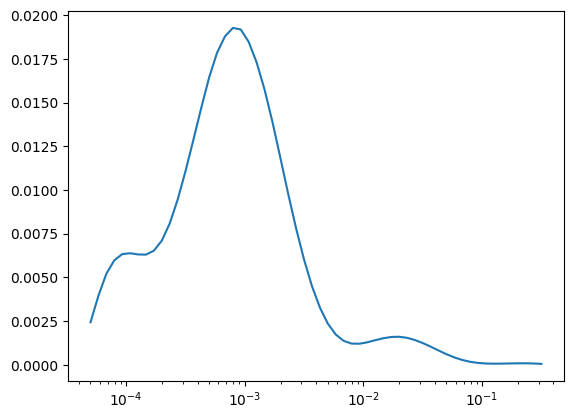

DRT spectrum 1 already exists
Spectrum 1/1 successfully saved
1


In [27]:

sample_spectrum_number = 0
series = 0
for file_in in (s321['files']):
    print(file_in)

    # newpath = mea['folder']+'PROCESSED_EIS/'
    newpath = "C:/Users/Herman/Desktop/"
    if not os.path.exists(newpath):
        os.makedirs(newpath)   
    file_out = newpath+os.path.basename(file_in[:-4])+'_DRT.h5'
    # cycles = np.linspace(1,100,100)
    # print(cycles)
    sample_spectrum_number,series = calculate_DRT(file_in,file_out,sample_spectrum_number,series,cycles = [9])
    # save_impedance_to_h5(file_in, file_out)
    print(series)

In [65]:
a = 1.0
print(unique_vals)

NameError: name 'unique_vals' is not defined

In [8]:
eis = pyDRTtools.runs.EIS_object.from_file(r"C:/Users/Herman/Desktop/V_Day3_procedure1_05_PEIS_C01.mpt")

UnboundLocalError: local variable 'freq' referenced before assignment

In [40]:
pyDRTtools.runs.Bayesian_run(eis,NMC_sample=20)

The epsilon factor is:  2.214639975241986
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.0001687518152456224
            Iterations: 9
            Function evaluations: 29
            Gradient evaluations: 9
GCV
The value of the regularization parameter is [1.00185984e-07]
[2.73833764e-03 1.74110941e-03 1.19309556e-03 9.11207905e-04
 7.59272892e-04 6.57855666e-04 5.71934902e-04 4.91625729e-04
 4.17116834e-04 3.50462581e-04 2.92614389e-04 2.43217857e-04
 2.01261078e-04 1.65630809e-04 1.35362930e-04 1.09673798e-04
 8.79019626e-05 6.94654364e-05 5.39061506e-05 4.10046197e-05
 3.08162026e-05 2.35084356e-05 1.91471387e-05 1.77050011e-05
 1.93690777e-05 2.52437441e-05 3.98154438e-05 8.96383946e-05
 1.23778798e+01 5.05600480e+01 6.82793092e-05 2.89006500e-05
 1.83157963e-05 1.38803536e-05 1.21969769e-05 1.24807567e-05
 1.49257329e-05 2.05730489e-05 3.15637234e-05 5.17420907e-05
 8.81302203e-05 1.54583878e-04 2.80004934e-04 5.24645602e-04
 1.0085229

KeyboardInterrupt: 

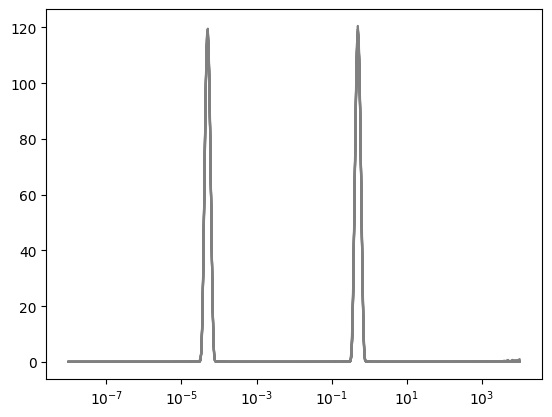

In [37]:
# upper_bound = basics.x_to_gamma(np.quantile(eis.Xs[:,10:],.995,axis=1), eis.tau_fine, eis.tau, eis.epsilon, 'Gaussian')
for i in range(0,12):
    gamma = basics.x_to_gamma(eis.Xs[:,i], eis.tau, eis.tau, eis.epsilon, 'Gaussian')
    # print(gamma)
    plt.plot(gamma[0],gamma[1],'grey')
    # plt.plot(gamma[0],gamma[1]-upper_bound[1],'blue')
    # plt.plot(eis.Xs[:,i]-np.quantile(eis.Xs[:,:],.005,axis=1))
# plt.plot()
# plt.plot(eis.out_tau_vec,eis.upper_bound,'--',c='red')
# plt.plot(eis.out_tau_vec,eis.lower_bound,'--',c='blue')
# plt.xlim(1e-3,1e2)
    
plt.xscale('log')
plt.show()


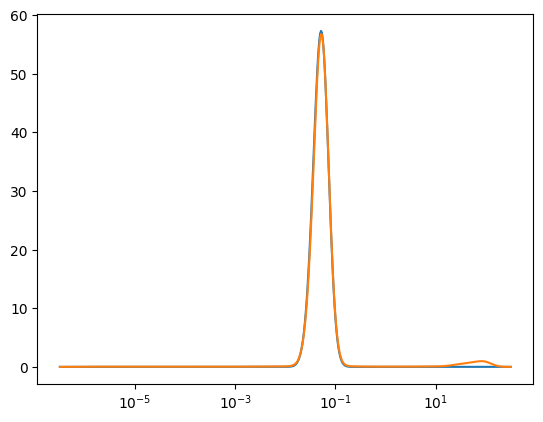

In [5]:
# plt.plot(eis.out_tau_vec,eis.upper_bound)
# plt.plot(eis.out_tau_vec,eis.lower_bound)
plt.plot(eis.out_tau_vec,eis.gamma)
plt.plot(eis.out_tau_vec,eis.mean)
plt.xscale('log')
plt.show()

In [41]:
# BHT_run
pyDRTtools.runs.BHT_run(eis)

sigma_n; sigma_beta; sigma_lambda
2.22511e+01     277.622321     0.063172 
-6.91935e+00     277.411932     0.649950 
-7.97146e+00     277.404327     0.688234 
-6.45798e+00     277.414190     0.810900 
-3.55402e+00     277.431248     1.110482 
-3.15988e+00     277.427361     1.546531 
-1.38960e+00     277.428297     2.292975 
-4.98725e-01     277.410503     3.555900 
-5.28268e-01     277.383464     4.836152 
4.48993e-01     277.312911     8.511591 
2.09413e-01     277.319742     8.011319 
1.42102e-01     277.319598     7.955994 
8.31989e-02     277.309932     8.253392 
4.98391e-02     277.290175     8.916388 
3.19727e-02     277.258188     9.996498 
3.02197e-02     277.202449     11.837825 
-2.12136e-02     277.060136     16.434749 
6.76897e-03     277.080822     15.702473 
1.12504e-02     277.079425     15.736250 
1.07650e-02     277.078772     15.754962 
9.16569e-03     277.076566     15.775173 
7.65724e-03     277.073453     15.806010 
8.09524e-03     277.070481     15.804195 
8.5281

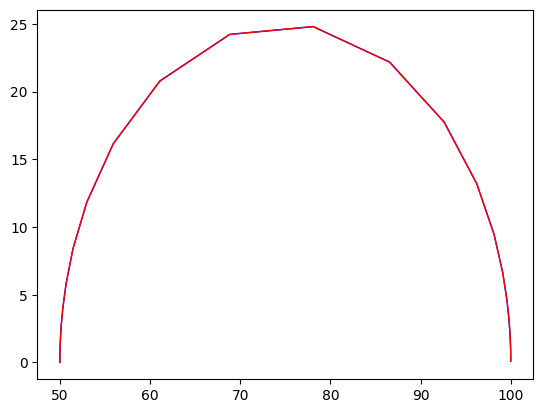

In [46]:
plt.plot(eis.mu_Z_H_re_agm, -eis.mu_Z_H_im_agm, 'b', linewidth=1)
plt.plot(eis.Z_prime_0, -eis.Z_double_prime_0, 'r', linewidth=1)
# plt.semilogx(eis.out_tau_vec, eis.mu_gamma_fine_im, 'k', linewidth=1)

## OLD CELLS

In [ ]:
def calculate_DRT(file_in,file_out, cycles, lambda_value = 0):
    freq_vec_old = [1,2]
    print(file_in)
#     print((n-n%3)/3)
#     file = s244['files'][int((n-n%3)/3)]
    # file = s244['files'][n]
    skip_rows = get_header_lines(file_in)
    with open(file_in, encoding='latin1') as f:
        df = pd.read_csv(f,skiprows = skip_rows-1,usecols=np.arange(0,30),delimiter = '\t')
        
        
    unique_vals = np.unique(df["cycle number"].values)
    # groups = [data[df["cycle number"].values == val] for val in unique_vals]
    
    # R_inf_DRT_list = []
    # L_0_DRT_list = []
    DRT_list = []
    # Z_DRT_list = [0]*len(unique_vals)
    # Z_exp_list = [0]*len(unique_vals)
    Z_exp_list = []
    freq_list = []
    # log_tau_list = []
    # lambda_value = 0.02
    rows = []
    spectra = []
    metadata_list = []
    for val in unique_vals[cycles[0]:cycles[1]]:
        freq_vec = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'freq/Hz'].values)
        # Z_exp = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'Re(Z)/Ohm'].values - 1j*df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '-Im(Z)/Ohm'].values)
        Z_exp = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), 'Re(Z)/Ohm'].values - 1j*df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '-Im(Z)/Ohm'].values)
       
        # Z_exp = np.flip(Z_exp)
        # freq_vec = np.flip(freq_vec)
        I = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '<I>/mA'].values)
        E = (df.loc[(df["cycle number"] == val) & (df["freq/Hz"] != 0), '<Ewe>/V'].values)
        if np.diff(freq_vec).any() <  0:
            print('problem')
        else:
            pass

        
        mask = (freq_vec > 0.001)  & (freq_vec <= 2e4)
        mask &= np.isfinite(Z_exp.real) & np.isfinite(Z_exp.imag)


        freq_vec = freq_vec[mask]
        
        Z_exp = Z_exp[mask]
        Z_exp_list.append(Z_exp)
        # freq_vec_old = freq_vec

        if list(freq_vec) == list(freq_vec_old):
            pass
        else:
            freq_vec_old = freq_vec
            
            N_freqs = len(freq_vec)
            N_taus = N_freqs

            # log_tau_min = round(np.log10(6.28/max(freq_vec)),3)  
            # log_tau_max = round(np.log10(6.28/min(freq_vec)),3)   
            # tau_vec = np.logspace(log_tau_min, log_tau_max, num = N_taus, endpoint=True)
            tau_vec = 1/freq_vec
            # print(tau_vec)
            # log_tau_vec = np.log10(tau_vec)
            # log_tau_list.append(log_tau_vec)

            # print(log_tau_min,log_tau_max)

            epsilon  = basics.compute_epsilon(freq_vec, coeff, rbf_type, shape_control)

            # step 3: compute the differentiation matrices
            A_re = basics.assemble_A_re(freq_vec, tau_vec, epsilon, rbf_type)
            A_re_R_inf = np.ones((N_freqs, 1))
            A_re_L_0 = np.zeros((N_freqs, 1))
            A_re = np.hstack(( A_re_R_inf, A_re_L_0, A_re))
            A_im = basics.assemble_A_im(freq_vec, tau_vec, epsilon, rbf_type)
            A_im_R_inf = np.zeros((N_freqs, 1))
            A_im_L_0 = 2*np.pi*freq_vec.reshape((N_freqs, 1))
            A_im = np.hstack(( A_im_R_inf, A_im_L_0, A_im))
            A = np.vstack((A_re, A_im))

            # step 4: compute the differentiation matrix
            M2 = np.zeros((N_taus+2, N_taus+2))
            M2[2:,2:] = basics.assemble_M_2(tau_vec, epsilon, rbf_type)


        # step 5: compute the regularization parameter
        # lambda_value = basics.optimal_lambda(A_re, A_im, np.real(Z_exp), np.imag(Z_exp), M2, -3, 'GCV')
        
        if lambda_value ==0:
            lambda_value = basics.optimal_lambda(A_re, A_im, np.real(Z_exp), np.imag(Z_exp),  M2,'both',    'yes',     # no inductive part handling
            -5,       # starting log10(lambda) (the code will scan from here)
            'GCV'     # generalized cross-validation
                )
        # print(lambda_value)
        
        # lambda_value = [0.002]
        
        # print('lambda', lambda_value)
        # step 6: recover the DRT
        ### 
        lb = np.zeros([N_taus+2])
        bound_mat = np.eye(lb.shape[0])
        H_combined, c_combined = basics.quad_format_combined(A_re, A_im, np.real(Z_exp), np.imag(Z_exp), M2, lambda_value)
        
        # set bound constraint
        G = matrix(-np.identity(Z_exp.imag.shape[0]+2))
        h = matrix(np.zeros(Z_exp.imag.shape[0]+2))
        sol = solvers.qp(matrix(H_combined), matrix(c_combined),G,h)
        ## deconvolved DRT
        x = np.array(sol['x']).flatten()
        out_tau,gamma = basics.x_to_gamma(x[2:], tau_vec, tau_vec, epsilon, rbf_type)
        # R_inf_DRT_list.append(x[0])
        # L_0_DRT_list.append(x[1])
        metadata = {'E' : np.mean(E),
                              'I' : np.mean(I),
                              'lambda' : lambda_value[0],
                              'Ro' : x[0],
                              'L' : x[1],
                              'Regularization Derivative' : 2,
                              'Discretization' : rbf_type,
                              'Shape Control' : shape_control,
                              'Coeff' : coeff,
                              'cv_type' : cv_type
                             }
        # spectra.append((out_tau,gamma))
        # DRT_list.append(np.concatenate(([val,lambda_value[0]],x)))
        # metadata_list.append({'E' : np.mean(E),
        #                       'I' : np.mean(I),
        #                       'lambda' : lambda_value[0],
        #                       'Ro' : x[0],
        #                       'L' : x[1],
        #                       'Regularization Derivative' : 2,
        #                       'Discretization' : rbf_type,
        #                       'Shape Control' : shape_control,
        #                       'Coeff' : coeff,
        #                       'cv_type' : cv_type
        #                      })
        save_spectra_h5(file_out, out_tau,gamma, val, metadata) 
        # for t,g in zip(out_tau,gamma):
            # rows.append([val,t,g,x[0],x[1],lambda_value[0],np.mean(E),np.mean(I)])
            # print([val,f,g,x[0],x[1]])

        # tau = 6.28/freq_vec       # s

#         Z = drt_to_impedance(out_tau, gamma, freq_vec, R_inf=x[0], L=x[1])
#         # print(mea['L'][52+x])

#         # Nyquist plot
#         plt.figure()
#         plt.plot(Z.real, -Z.imag, 'o-')
#         plt.plot(Z_exp.real, -Z_exp.imag, 'x', c = 'red')
        
#         # plt.xlabel("Z' (Ω)")
#         # plt.ylabel("-Z'' (Ω)")
#         plt.title("Nyquist Plot from DRT")
#         plt.axis('equal')
#         plt.grid(True)
#         # plt.title(str(x+1))
#         plt.show()
            
#         plt.plot(np.log10(out_tau),x[2:])
#         plt.show()
#         # print(log_tau_vec,x[2:])
            
            
            
    # plt.xscale('log')
    # plt.show()

    # E = get_potential_control(file_in)
    # if E == 'Ewe':
    #     columns = ['freq/Hz', 'Re(Z)/Ohm','-Im(Z)/Ohm','<Ewe>/V','time/s','<I>/mA']
    # elif E == 'Ecell':
    #     columns = ['freq/Hz', 'Re(Zwe-ce)/Ohm','-Im(Zwe-ce)/Ohm','<Ewe>/V','time/s','<I>/mA']
     
    # save_impedance_to_h5(file_in, file_out, columns, cycle_col="cycle number",cycles = [1,3], global_metadata=None)
  
        
    # header = 'cycle number\tfreq/Hz\tgamma\tR0/Ohm\tL/H\tlambda\t<Ewe>/V\t<I>/mA'    
    # np.savetxt(newpath+os.path.basename(file[:-4])+'_Zwe_DRT.txt', rows, delimiter='\t',header = header, comments='')



In [ ]:
f = np.loadtxt(mea['folder']+'PROCESSED_EIS/'+os.path.basename(file[:-4])+'_Zwe_DRT.txt',skiprows = 1)
fR = np.loadtxt(mea['folder']+'PROCESSED_EIS/relaxis DRT.txt',skiprows = 2)
print(np.array(f[:,1]))
plt.plot(f[:,1],2.13*f[:,2])
plt.plot(1/fR[:,0],fR[:,1])
plt.xscale('log')
# plt.yscale('log')
plt.show()

Z = drt_to_impedance(6.28/fR[:,0], fR[:,1], fR[:,0], R_inf=50, L=0)
# plt.plot((6.28/fR[:,0]), -Z.real, 'x')
# plt.plot(Z.real, -Z.imag, 'o-')

Z = drt_to_impedance(6.28/f[:,1], 2.13*f[:,2], f[:,1], R_inf=50, L=0)
# plt.plot((6.28/f[:,1]), -Z.real, 'x')
# plt.plot(Z.real, -Z.imag, 'o-')

plt.plot((tau), -Z_exp.real +Z.real, 'x')
plt.xscale('log')
plt.show()